### This notebook reproduces the maximum amplification contour plot figure from the paper. The data for the figure are available under max_amplification_outputs directory. This is jut a plotting script. If you want to generate the data use maximum_amplification_grid.py and run this on a cluster.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange
import sys

# plt.style.use("./science.mplstyle")

import smplotlib

codedir = "../src/"

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import griddata

sys.path.append(os.path.abspath(codedir))

from axisymmetric_stability import *

In [2]:
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D
import numpy as np


def overlay_Rafikov_axisymmetric_stability_boundary(
    ax,
    Qg_vec,
    Qs_vec,
    hg,
    hs,
    R,
    sigma=1.5,
    color="black",
    linestyle="solid",
    linewidth=1.5,
    add_legend=False,
    legend_loc="upper right",
):
    """
    Overlay the Rafikov axisymmetric stability boundary on an existing axis.

    Parameters
    ----------
    ax : matplotlib axis
        Axis on which to overlay the boundary.

    Qg_vec, Qs_vec : 1D arrays
        Arrays of Qg and Qs values.

    hg, hs, R : float
        Disk parameters.

    sigma : float
        Gaussian smoothing width.

    add_legend : bool
        If True, add a legend entry for the stability boundary.
    """

    Z = get_stability_boundary_thick_disk(R, Qg_vec, Qs_vec, hg, hs)
    Z_smooth = gaussian_filter(Z, sigma=sigma)

    cs = ax.contour(
        1.0 / Qs_vec,   # x-axis = 1/Qs
        1.0 / Qg_vec,   # y-axis = 1/Qg
        Z_smooth,
        levels=[0.5],
        colors=[color],
        linewidths=linewidth,
        linestyles=linestyle,
        zorder=20,
    )

    if add_legend:
        style_handle = Line2D(
            [0], [0],
            color=color,
            lw=linewidth,
            ls=linestyle,
            label=r"Stability boundary",
        )
        ax.legend(handles=[style_handle], loc=legend_loc)

    return cs

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D


def make_auto_log_levels(values, n_levels=12, min_level=1.0):
    """
    Make clean log-spaced contour levels using a 1-2-5 sequence.
    """

    values = np.asarray(values)
    values = values[np.isfinite(values)]
    values = values[values > 0.0]

    if len(values) == 0:
        raise ValueError("No positive finite values available for automatic levels.")

    vmin = max(np.nanpercentile(values, 2), min_level)
    vmax = np.nanpercentile(values, 98)

    if vmax <= vmin:
        vmax = np.nanmax(values)

    # Candidate nice levels: 1, 2, 5 times powers of 10
    pmin = int(np.floor(np.log10(vmin)))
    pmax = int(np.ceil(np.log10(vmax)))

    candidates = []
    for p in range(pmin, pmax + 1):
        for m in [1, 2, 5]:
            val = m * 10.0**p
            if vmin <= val <= vmax:
                candidates.append(val)

    candidates = np.array(candidates)

    if len(candidates) < 2:
        candidates = np.geomspace(vmin, vmax, n_levels)

    return candidates


def plot_max_amplification_contour_with_Rafikov_boundary(
    data_to_plot,
    n_fine=500,
    levels=None,
    n_levels=12,
    cmap_name="turbo",
    interp_method="cubic",
    boundary_sigma=1.5,
    boundary_color="black",
    boundary_linestyle="solid",
    boundary_linewidth=1.8,
    show_contour_lines=True,
    contour_line_color="black",
    contour_linewidth=0.45,
    contour_line_alpha=0.45,
    add_boundary_legend=True,
    unstable_text=True,
    unstable_text_xy=(1.0, 1.2),
    colorbar_tick_step=1,
    figsize=(5, 4),
    save=False,
    filename=None,
    abcd_text =0,
    abcd_text_val =None,
    abcd_text_loc = None,
):
    """
    Plot maximum swing amplification contours in the (1/Qs, 1/Qg) plane
    and overlay the Rafikov axisymmetric stability boundary.

    Required keys in data_to_plot:
        data_to_plot["Qg_vec"]
        data_to_plot["Qs_vec"]
        data_to_plot["max_amplification_arr"]
        data_to_plot["R"]
        data_to_plot["hg"]
        data_to_plot["hs"]

    Axis convention:
        x-axis = 1 / Qs
        y-axis = 1 / Qg
    """

    Qg_vec = np.asarray(data_to_plot["Qg_vec"])
    Qs_vec = np.asarray(data_to_plot["Qs_vec"])
    max_amp = np.asarray(data_to_plot["max_amplification_arr"])

    print(len(Qg_vec))
    print(len(Qs_vec))

    R = data_to_plot["R"]
    hg = data_to_plot["hg"]
    hs = data_to_plot["hs"]

    # --------------------------------------------------
    # Convert axes to inverse Q
    # --------------------------------------------------
    inv_Qg_vec = 1.0 / Qg_vec
    inv_Qs_vec = 1.0 / Qs_vec

    # --------------------------------------------------
    # Sort axes because 1/Q may reverse original ordering
    # --------------------------------------------------
    sort_g = np.argsort(inv_Qg_vec)
    sort_s = np.argsort(inv_Qs_vec)

    inv_Qg_vec_sorted = inv_Qg_vec[sort_g]
    inv_Qs_vec_sorted = inv_Qs_vec[sort_s]

    Qg_vec_sorted = Qg_vec[sort_g]
    Qs_vec_sorted = Qs_vec[sort_s]

    max_amp_sorted = max_amp[np.ix_(sort_g, sort_s)]

    # --------------------------------------------------
    # Original grid
    # max_amp_sorted[i, j] corresponds to
    # inv_Qg_vec_sorted[i], inv_Qs_vec_sorted[j]
    # --------------------------------------------------
    INV_QG, INV_QS = np.meshgrid(
        inv_Qg_vec_sorted,
        inv_Qs_vec_sorted,
        indexing="ij",
    )

    finite_mask = np.isfinite(max_amp_sorted)

    points = np.column_stack([
        INV_QG[finite_mask],
        INV_QS[finite_mask],
    ])

    values = max_amp_sorted[finite_mask]

    if len(values) == 0:
        raise ValueError("No finite values found in max_amplification_arr.")

    # --------------------------------------------------
    # Fine grid
    # --------------------------------------------------
    inv_Qg_fine = np.linspace(
        inv_Qg_vec_sorted.min(),
        inv_Qg_vec_sorted.max(),
        n_fine,
    )

    inv_Qs_fine = np.linspace(
        inv_Qs_vec_sorted.min(),
        inv_Qs_vec_sorted.max(),
        n_fine,
    )

    INV_QG_FINE, INV_QS_FINE = np.meshgrid(
        inv_Qg_fine,
        inv_Qs_fine,
        indexing="ij",
    )

    # --------------------------------------------------
    # Interpolate only over stable / finite region
    # --------------------------------------------------
    max_amp_fine = griddata(
        points,
        values,
        (INV_QG_FINE, INV_QS_FINE),
        method=interp_method,
    )

    max_amp_fine = np.ma.masked_invalid(max_amp_fine)
    max_amp_fine = np.ma.masked_where(max_amp_fine <= 0.0, max_amp_fine)

    finite_fine_values = max_amp_fine.compressed()

    if len(finite_fine_values) == 0:
        raise ValueError("No positive finite values after interpolation.")

    # --------------------------------------------------
    # Automatic contour levels
    # --------------------------------------------------
    if levels is None:
        levels = make_auto_log_levels(
            finite_fine_values,
            n_levels=n_levels,
            min_level=1.0,
        )
    else:
        levels = np.asarray(levels)
        levels = levels[levels > 0.0]
        levels = np.unique(np.sort(levels))

    if len(levels) < 2:
        raise ValueError("Need at least two positive contour levels.")

    norm = LogNorm(vmin=levels[0], vmax=levels[-1])

    # --------------------------------------------------
    # Plot
    # x-axis = 1/Qs
    # y-axis = 1/Qg
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    contf = ax.contourf(
        INV_QS_FINE,
        INV_QG_FINE,
        max_amp_fine,
        levels=levels,
        cmap=cmap_name,
        norm=norm,
        extend="both",
    )

    # Optional contour lines, without numbers
    if show_contour_lines:
        ax.contour(
            INV_QS_FINE,
            INV_QG_FINE,
            max_amp_fine,
            levels=levels,
            colors=contour_line_color,
            linewidths=contour_linewidth,
            alpha=contour_line_alpha,
        )

    # --------------------------------------------------
    # Overlay Rafikov stability boundary
    # --------------------------------------------------
    Z_stability = get_stability_boundary_thick_disk(
        R,
        Qg_vec_sorted,
        Qs_vec_sorted,
        hg,
        hs,
    )

    Z_stability_smooth = gaussian_filter(
        Z_stability,
        sigma=boundary_sigma,
    )

    boundary = ax.contour(
        1.0 / Qs_vec_sorted,
        1.0 / Qg_vec_sorted,
        Z_stability_smooth,
        levels=[0.5],
        colors=[boundary_color],
        linewidths=boundary_linewidth,
        linestyles=boundary_linestyle,
        zorder=20,
    )

    # --------------------------------------------------
    # Colorbar with numbers
    # --------------------------------------------------
    cbar_ticks = levels[::colorbar_tick_step]

    if cbar_ticks[-1] != levels[-1]:
        cbar_ticks = np.append(cbar_ticks, levels[-1])

    cbar = fig.colorbar(
        contf,
        ax=ax,
        ticks=cbar_ticks,
    )

    cbar.set_label(r"max. amplification")
    cbar.ax.set_yticklabels([rf"${tick:g}$" for tick in cbar_ticks])

    cbar.ax.tick_params(
        which="major",
        direction="in",
        length=5,
    )

    # --------------------------------------------------
    # Labels and annotations
    # --------------------------------------------------
    ax.set_xlabel(r"$1/Q_{\rm s}$")
    ax.set_ylabel(r"$1/Q_{\rm g}$")

    ax.set_title(
        rf"$r={R}$, $h_s={hs}$, $h_g={hg}$", fontsize=14,
    )

    if unstable_text:
        ax.text(
            unstable_text_xy[0],
            unstable_text_xy[1],
            "unstable",
            ha="center",
            va="center",
            fontsize=14,
        )

    if abcd_text:
        ax.text(
            abcd_text_loc[0],
            abcd_text_loc[1],
            abcd_text_val,
            ha="center",
            va="center",
            fontsize=14,
        )

    if add_boundary_legend:
        boundary_handle = Line2D(
            [0], [0],
            color=boundary_color,
            lw=boundary_linewidth,
            ls=boundary_linestyle,
            label="stability boundary",
        )

        ax.legend(
            handles=[boundary_handle],
            loc="upper right",
            frameon=False,
            fontsize=14,
        )

    ax.tick_params(
        which="major",
        direction="in",
        top=True,
        right=True,
        length=6,
    )

    ax.tick_params(
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=3,
    )

    fig.tight_layout()

    if save:
        if filename is None:
            filename = f"../Figures/max_amp_{R}_{hg}_{hs}.pdf"

        fig.savefig(filename, bbox_inches="tight")

    return fig, ax, boundary

In [4]:
def get_data(R,hg,hs):
    
    return np.load(f"./max_amplification_outputs/{R}_{hg}_{hs}.npz")


100
100
100
100
100
100
100
100


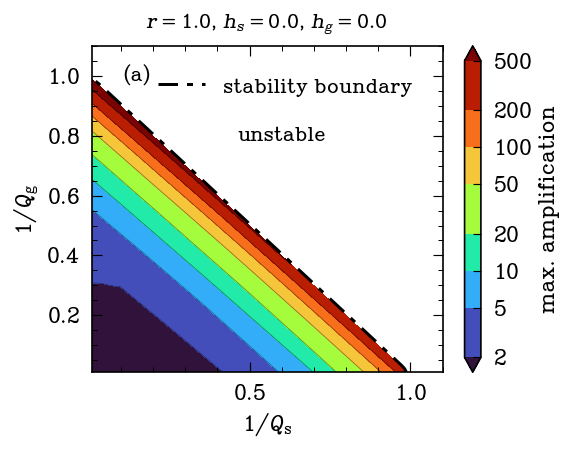

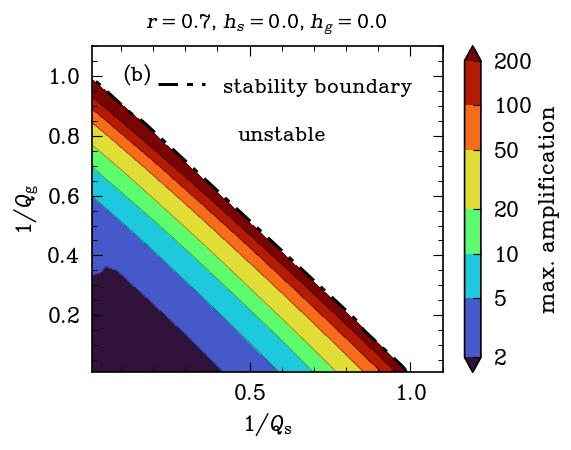

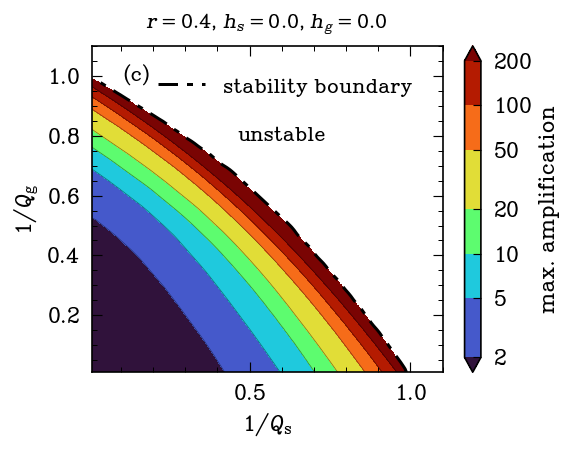

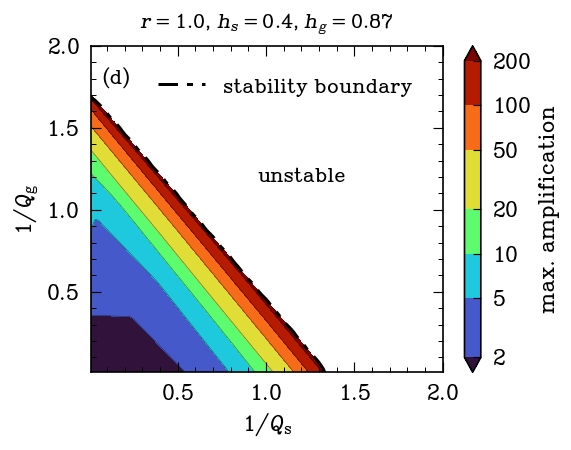

In [6]:
data_values = [[1.0,0.0,0.0, (0.6, 0.8),"(a)", [0.15, 1.0]], 
              [0.7,0.0,0.0, (0.6, 0.8), "(b)", [0.15, 1.0]], 
              [0.4,0.0,0.0, (0.6, 0.8), "(c)", [0.15, 1.0]],
              [1.0,0.87,0.4,(1.2, 1.2), "(d)", [0.15, 1.8]],
              ]

for vals in data_values:
    R = vals[0]
    hg = vals[1]
    hs = vals[2]
    unstable_text_xy = vals[3]
    abcd_text_val = vals[4]
    abcd_text_loc = vals[5]

    data_to_plot = get_data(R,hg,hs)


    fig, ax, boundary = plot_max_amplification_contour_with_Rafikov_boundary(
    data_to_plot,
    boundary_color="black",
     boundary_linestyle="-.",
    boundary_linewidth=1.8,
    save=True,
    filename=f"./Figures/max_amplification_grid_{R}_{hg}_{hs}.pdf",
    # unstable_text_xy=(0.5, 0.8)
    unstable_text_xy=unstable_text_xy,
    abcd_text =1,
    abcd_text_val = abcd_text_val ,
    abcd_text_loc = abcd_text_loc
)

plt.show()